In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/20-digitalskysurvey.csv")

In [5]:
df.shape

(10000, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


In [7]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [8]:
df.isnull().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64

In [9]:
df["class"].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

In [10]:
df.nunique()

objid            1
ra           10000
dec          10000
u             9730
g             9817
r             9852
i             9890
z             9896
run             23
rerun            1
camcol           6
field          703
specobjid     6349
class            3
redshift      9637
plate          487
mjd            355
fiberid        892
dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
label = LabelEncoder()

In [20]:
df["class_encoded"] = label.fit_transform(df["class"])

In [23]:
df = df.drop("class", axis=1)

In [24]:
df.corr()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid,class_encoded
objid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ra,NaN,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.092741,NaN,-0.006294,0.594700,-0.095327,0.030307,-0.095329,-0.086887,0.057485,-0.043219
dec,NaN,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,0.778385,NaN,0.114614,-0.131471,0.088345,0.067021,0.088342,0.066147,0.155012,-0.058918
u,NaN,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,0.038229,NaN,0.009945,0.008548,-0.129429,0.163741,-0.129430,-0.168793,0.011301,-0.269044
g,NaN,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,0.058446,NaN,0.010223,0.014651,-0.054979,0.407576,-0.054981,-0.092772,0.047187,-0.099212
r,NaN,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.057261,NaN,0.010747,0.017133,0.019788,0.441080,0.019787,-0.009345,0.061081,0.049628
i,NaN,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.049765,NaN,0.013461,0.019781,0.072960,0.431450,0.072958,0.050896,0.069977,0.146791
z,NaN,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.048252,NaN,0.010930,0.018248,0.112398,0.424034,0.112397,0.095658,0.067980,0.215758
run,NaN,-0.092741,0.778385,0.038229,0.058446,0.057261,0.049765,0.048252,1.000000,NaN,0.151814,-0.463898,0.093604,0.059056,0.093601,0.070354,0.138566,-0.078162
rerun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df = df.drop(columns=["objid", "rerun"])

In [28]:
df.corr()

,ra,dec,u,g,r,i,z,run,camcol,field,specobjid,redshift,plate,mjd,fiberid,class_encoded
ra,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.092741,-0.006294,0.594700,-0.095327,0.030307,-0.095329,-0.086887,0.057485,-0.043219
dec,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,0.778385,0.114614,-0.131471,0.088345,0.067021,0.088342,0.066147,0.155012,-0.058918
u,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,0.038229,0.009945,0.008548,-0.129429,0.163741,-0.129430,-0.168793,0.011301,-0.269044
g,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,0.058446,0.010223,0.014651,-0.054979,0.407576,-0.054981,-0.092772,0.047187,-0.099212
r,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.057261,0.010747,0.017133,0.019788,0.441080,0.019787,-0.009345,0.061081,0.049628
i,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.049765,0.013461,0.019781,0.072960,0.431450,0.072958,0.050896,0.069977,0.146791
z,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.048252,0.010930,0.018248,0.112398,0.424034,0.112397,0.095658,0.067980,0.215758
run,-0.092741,0.778385,0.038229,0.058446,0.057261,0.049765,0.048252,1.000000,0.151814,-0.463898,0.093604,0.059056,0.093601,0.070354,0.138566,-0.078162
camcol,-0.006294,0.114614,0.009945,0.010223,0.010747,0.013461,0.010930,0.151814,1.000000,-0.067921,0.040809,0.006834,0.040795,0.026284,0.535629,-0.006186
field,0.594700,-0.131471,0.008548,0.014651,0.017133,0.019781,0.018248,-0.463898,-0.067921,1.000000,-0.093724,0.015414,-0.093723,-0.086558,-0.040493,0.007713


<Axes: >

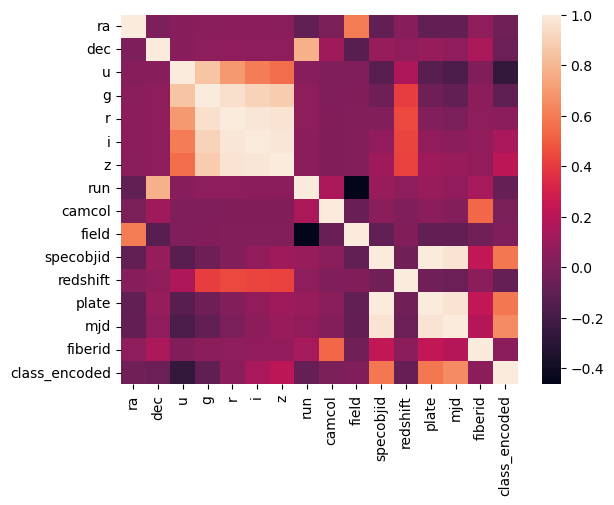

In [29]:
sns.heatmap(df.corr())

<Axes: xlabel='redshift', ylabel='Density'>

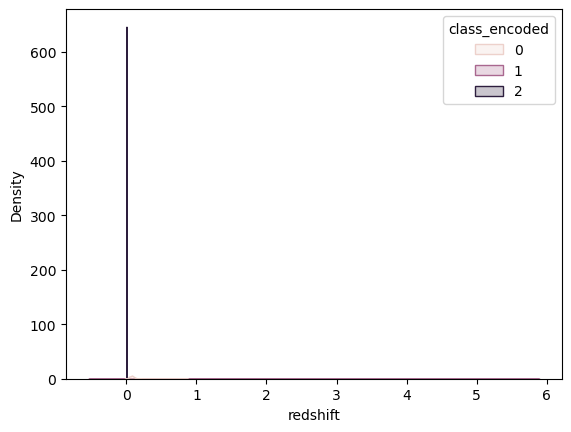

In [41]:
sns.kdeplot(data=df, x="redshift", hue="class_encoded", fill=True)

<Axes: xlabel='class_encoded', ylabel='redshift'>

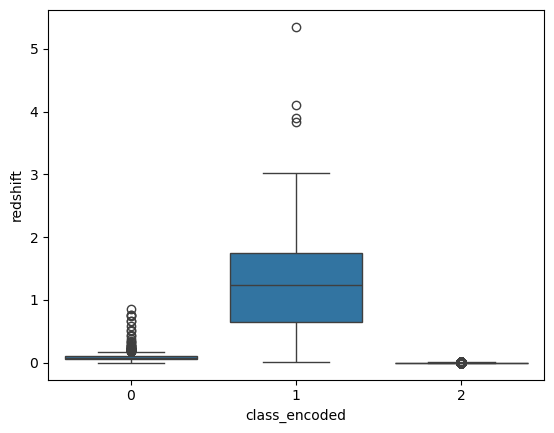

In [43]:
sns.boxplot(data=df, x="class_encoded", y="redshift")

In [46]:
df = df.drop(columns = ["specobjid", "plate", "mjd"], axis = 1)

In [47]:
df.columns

Index(['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'camcol', 'field',
       'redshift', 'fiberid', 'class_encoded'],
      dtype='object')

In [48]:
from sklearn.linear_model import LogisticRegression

### Model Kurulumları

In [49]:
logistic = LogisticRegression()

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X = df.drop("class_encoded", axis = 1)
y = df["class_encoded"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size = 0.2
)

In [53]:
logistic.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_pred = logistic.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score

In [56]:
print("score: ", accuracy_score(y_test, y_pred))
print("classification: ", classification_report(y_test, y_pred))
print("confusion_matrix: ", confusion_matrix(y_test, y_pred))
print("train_score: ", logistic.score(X_train, y_train))
print("test_score: ", logistic.score(X_test, y_test))

score:  0.5775
classification:                precision    recall  f1-score   support

           0       0.64      0.70      0.67       996
           1       0.00      0.00      0.00       190
           2       0.50      0.56      0.53       814

    accuracy                           0.58      2000
   macro avg       0.38      0.42      0.40      2000
weighted avg       0.52      0.58      0.55      2000

confusion_matrix:  [[697   0 299]
 [ 35   0 155]
 [351   5 458]]
train_score:  0.565875
test_score:  0.5775


In [57]:
label.classes_

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

### Lojistik Regresyon Yorumu

- İlk olarak lojistik regresyon denememizin sebebi, sınıfların birbirinden lineer olarak ayrışıp ayrışmadığını ölçmekti. 
- Bakıldığında class 0 ve class 2 birbirinden lineer olarak ayrıştığından model bu noktada iyi tahminler yapmış sayabiliriz.
- Ancak class 1 hiç öğrenilememiş, bu da bu classın lineer olarak diğer modellerden ayrışamadığının kanıtıdır.

### Decision Tree

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
tree = DecisionTreeClassifier(
    max_depth= None
)

In [60]:
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [61]:
y_pred = tree.predict(X_test)

In [63]:
print("score: ", accuracy_score(y_test, y_pred))
print("classification: ", classification_report(y_test, y_pred))
print("confusion_matrix: ", confusion_matrix(y_test, y_pred))
print("train_score: ", tree.score(X_train, y_train))
print("test_score: ", tree.score(X_test, y_test))

score:  0.9845
classification:                precision    recall  f1-score   support

           0       0.98      0.99      0.99       996
           1       0.94      0.92      0.93       190
           2       1.00      1.00      1.00       814

    accuracy                           0.98      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000

confusion_matrix:  [[985   9   2]
 [ 16 174   0]
 [  2   2 810]]
train_score:  1.0
test_score:  0.9845


In [64]:
from sklearn.model_selection import GridSearchCV

In [83]:
params = {
    "max_depth": [2,3,4,5,5,6,7,8],
    "min_samples_leaf" : [5,6,7,8,9],
    "ccp_alpha": [0.0, 0.0001, 0.001, 0.01]
}

In [84]:
grid = GridSearchCV(
    estimator= DecisionTreeClassifier(), 
    param_grid= params,
    cv = 5,
    n_jobs= -1)

In [85]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [0.0, 0.0001, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 6, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [86]:
y_pred = grid.predict(X_test)

In [87]:
print("score: ", accuracy_score(y_test, y_pred))
print("classification: ", classification_report(y_test, y_pred))
print("confusion_matrix: ", confusion_matrix(y_test, y_pred))
print("train_score: ", grid.score(X_train, y_train))
print("test_score: ", grid.score(X_test, y_test))

score:  0.991
classification:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       996
           1       0.98      0.94      0.96       190
           2       1.00      1.00      1.00       814

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000

confusion_matrix:  [[990   4   2]
 [ 11 179   0]
 [  1   0 813]]
train_score:  0.993
test_score:  0.991


In [88]:
grid.best_params_

{'ccp_alpha': 0.0, 'max_depth': 6, 'min_samples_leaf': 5}

In [89]:
from sklearn.ensemble import RandomForestClassifier

In [90]:
rf = RandomForestClassifier()

In [91]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [92]:
print("score: ", accuracy_score(y_test, y_pred))
print("classification: ", classification_report(y_test, y_pred))
print("confusion_matrix: ", confusion_matrix(y_test, y_pred))
print("train_score: ", rf.score(X_train, y_train))
print("test_score: ", rf.score(X_test, y_test))

score:  0.9905
classification:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       996
           1       0.98      0.94      0.96       190
           2       0.99      1.00      1.00       814

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000

confusion_matrix:  [[988   3   5]
 [ 11 179   0]
 [  0   0 814]]
train_score:  1.0
test_score:  0.9905
